# La sorpresa de los andrógenos en el cerebro

**En la mayoría de los cánceres, los andrógenos (testosterona y compañía) ayudan al tumor.** Por eso bloquearlos es tratamiento estándar en cáncer de próstata.

**En el cerebro pasa lo contrario.** Quitarles los andrógenos a ratones con glioblastoma les acortó la vida 23%. Y en una cohorte de 1.272 hombres con el mismo tumor, los que recibieron testosterona suplementada tuvieron 38% menos riesgo de morir.

Veamos los datos.

---

**Paper:** [Androgen loss accelerates brain tumour growth via HPA axis activation](https://doi.org/10.1038/s41586-026-10451-5) — *Nature*, 2026
**Datos:** Source Data Fig. 1 y Fig. 3 (Supplementary Information del paper)
**Video:** [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-06-androgenos-glioblastoma-hpa/notebook.ipynb)


## El contexto

El glioblastoma (GBM) es el tumor cerebral más agresivo en adultos. Aparece más en hombres y mata más rápido a los hombres — y desde hace años se sospechaba que las hormonas masculinas estaban involucradas. La intuición clínica decía: si los andrógenos suprimen la respuesta inmune antitumoral (como pasa en otros cánceres), bloquearlos debería ayudar.

Este equipo del paper hizo el experimento — y se encontró con lo contrario. Castraron ratones con GBM intracraneal y los tumores crecieron más rápido. Después rastrearon el mecanismo (eje hipotálamo-pituitaria-adrenal, glucocorticoides, inmunidad de células T) y cruzaron el hallazgo con una cohorte humana.

Acá replicamos los dos experimentos centrales de supervivencia y verificamos el tamaño del efecto.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_SHAM       = '#2563EB'  # azul CaM — control intacto
COLOR_CAS        = '#DC2626'  # rojo — castrado
COLOR_VEH        = '#DC2626'  # rojo — castrado vehículo
COLOR_MFP        = '#059669'  # verde — castrado + mifepristona
COLOR_REFERENCIA = '#D97706'  # ámbar — líneas de referencia
FUENTE = 'Fuente: Garcia-Mulero et al. (2026), Nature | DOI: 10.1038/s41586-026-10451-5 | Datos: Source Data Fig. 1 y 3'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de datos
sb28 = pd.read_csv('datos/gbm_survival_sb28.csv')
mfp  = pd.read_csv('datos/mfp_rescue_castrated.csv')

print(f"Experimento 1 (Fig 1a) — Sham vs Castrado:")
print(f"  Sham: n={(sb28['grupo']=='Sham').sum()}, mediana={sb28[sb28['grupo']=='Sham']['dias_supervivencia'].median():.1f} días")
print(f"  Cas:  n={(sb28['grupo']=='Cas').sum()}, mediana={sb28[sb28['grupo']=='Cas']['dias_supervivencia'].median():.1f} días")
print()
print(f"Experimento 2 (Fig 3b) — Castrados con vehículo vs mifepristona:")
print(f"  Vehiculo:     n={(mfp['tratamiento']=='Vehiculo').sum()}, mediana={mfp[mfp['tratamiento']=='Vehiculo']['dias_supervivencia'].median():.1f} días")
print(f"  Mifepristona: n={(mfp['tratamiento']=='Mifepristona').sum()}, mediana={mfp[mfp['tratamiento']=='Mifepristona']['dias_supervivencia'].median():.1f} días")


Experimento 1 (Fig 1a) — Sham vs Castrado:
  Sham: n=13, mediana=26.0 días
  Cas:  n=14, mediana=20.0 días

Experimento 2 (Fig 3b) — Castrados con vehículo vs mifepristona:
  Vehiculo:     n=10, mediana=17.5 días
  Mifepristona: n=10, mediana=26.5 días


## Aquí están los ratones.

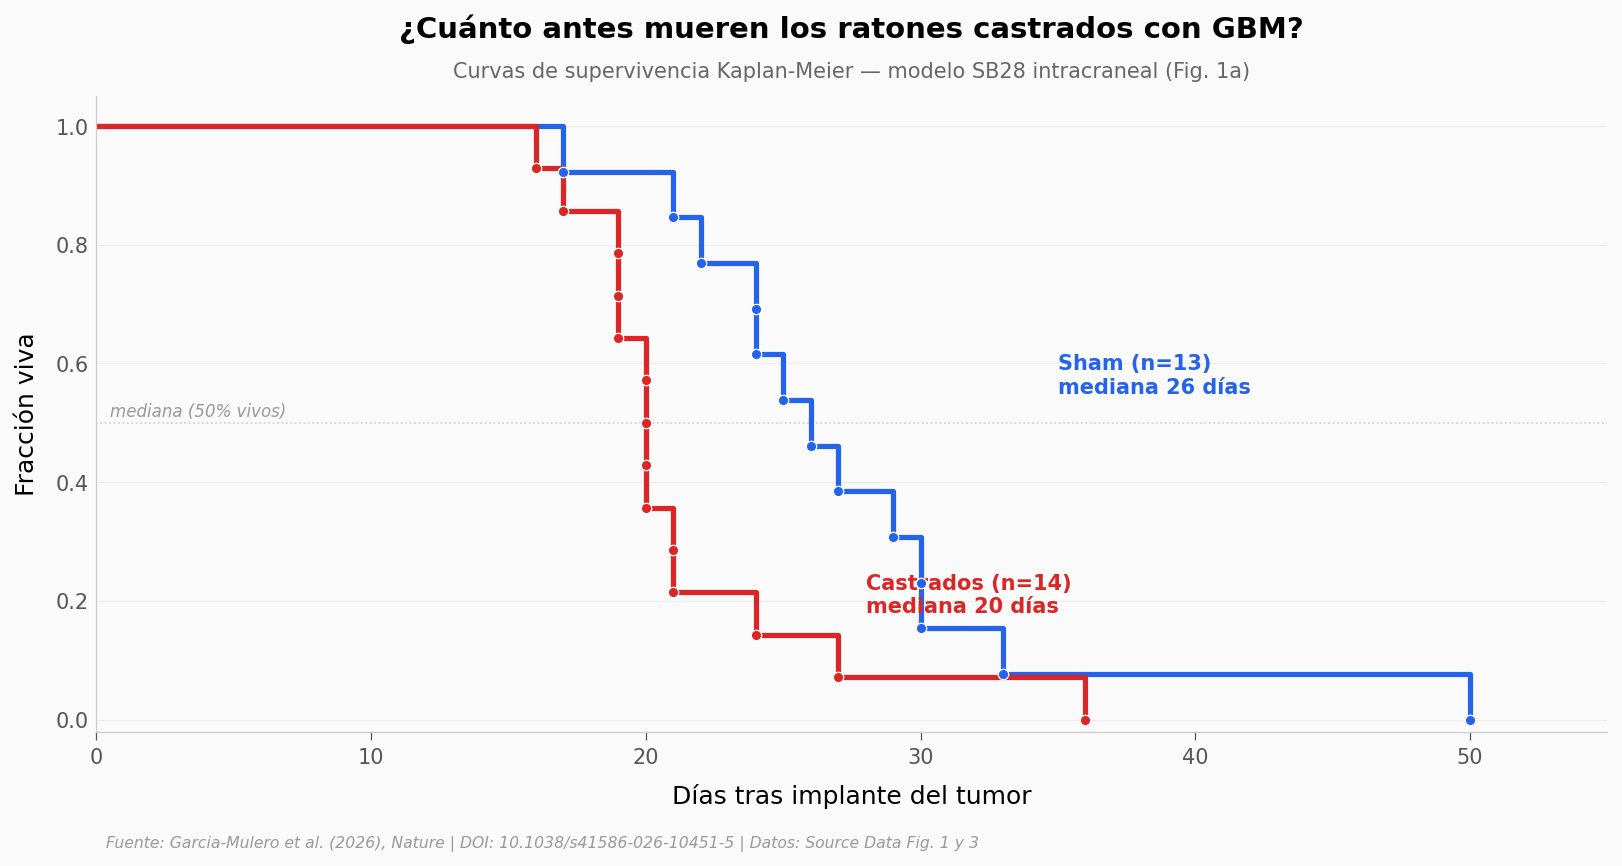

In [2]:
# Curva Kaplan-Meier manual (sin censura — todos los ratones alcanzaron endpoint)
def km_curve(times):
    times_sorted = np.sort(np.asarray(times, dtype=float))
    n = len(times_sorted)
    surv = np.array([(n - i) / n for i in range(n + 1)])
    t_steps = np.concatenate([[0], times_sorted])
    return t_steps, surv

sham_t = sb28[sb28['grupo'] == 'Sham']['dias_supervivencia'].values
cas_t  = sb28[sb28['grupo'] == 'Cas']['dias_supervivencia'].values

fig, ax = plt.subplots(figsize=(13, 5.5))

t_sham, s_sham = km_curve(sham_t)
t_cas,  s_cas  = km_curve(cas_t)

ax.step(t_sham, s_sham, where='post', color=COLOR_SHAM, linewidth=2.5, label='Sham (intactos)')
ax.step(t_cas,  s_cas,  where='post', color=COLOR_CAS,  linewidth=2.5, label='Castrados')

# Marcadores de eventos (cada muerte)
ax.scatter(sham_t, [(len(sham_t) - i - 1) / len(sham_t) for i in range(len(np.sort(sham_t)))],
           color=COLOR_SHAM, s=25, zorder=5, edgecolors='white', linewidths=0.6)
ax.scatter(cas_t, [(len(cas_t) - i - 1) / len(cas_t) for i in range(len(np.sort(cas_t)))],
           color=COLOR_CAS, s=25, zorder=5, edgecolors='white', linewidths=0.6)

# Inline labels (reemplaza legend box)
ax.text(35, 0.55, f'Sham (n={len(sham_t)})\nmediana 26 días',
        fontsize=10, color=COLOR_SHAM, fontweight='bold', ha='left')
ax.text(28, 0.18, f'Castrados (n={len(cas_t)})\nmediana 20 días',
        fontsize=10, color=COLOR_CAS, fontweight='bold', ha='left')

# Líneas guía de la mediana
ax.axhline(y=0.5, color='#BBBBBB', linewidth=0.8, linestyle=':', alpha=0.7, zorder=1)
ax.text(0.5, 0.51, 'mediana (50% vivos)', fontsize=8, color='#999999', style='italic')

ax.set_title('¿Cuánto antes mueren los ratones castrados con GBM?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Curvas de supervivencia Kaplan-Meier — modelo SB28 intracraneal (Fig. 1a)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Días tras implante del tumor')
ax.set_ylabel('Fracción viva')
ax.set_ylim(-0.02, 1.05)
ax.set_xlim(0, 55)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_km_sham_vs_cas.png', dpi=200, bbox_inches='tight')
plt.show()


La diferencia es visible y consistente: la curva roja se cae antes y más rápido. Los castrados pierden la mitad de la cohorte hacia el día 20, los intactos resisten hasta el día 26. Y la separación no aparece solo en el centro — el último ratón castrado muere antes que los últimos 3 intactos.

Para un experimento con n=27 ratones esto es bastante limpio. La pregunta natural: ¿qué pasa si bloqueamos lo que se activó al quitar los andrógenos?


## El rescate con mifepristona

Si la castración acelera el tumor porque dispara el eje HPA (hipotálamo-pituitaria-adrenal) y eso suelta glucocorticoides — las hormonas de estrés, como el cortisol — que apagan al sistema inmune, entonces bloquear ese receptor debería revertir el daño.

Eso es exactamente lo que hicieron: a ratones ya castrados con GBM les dieron mifepristona (antagonista del receptor de glucocorticoides) o vehículo, y midieron supervivencia.


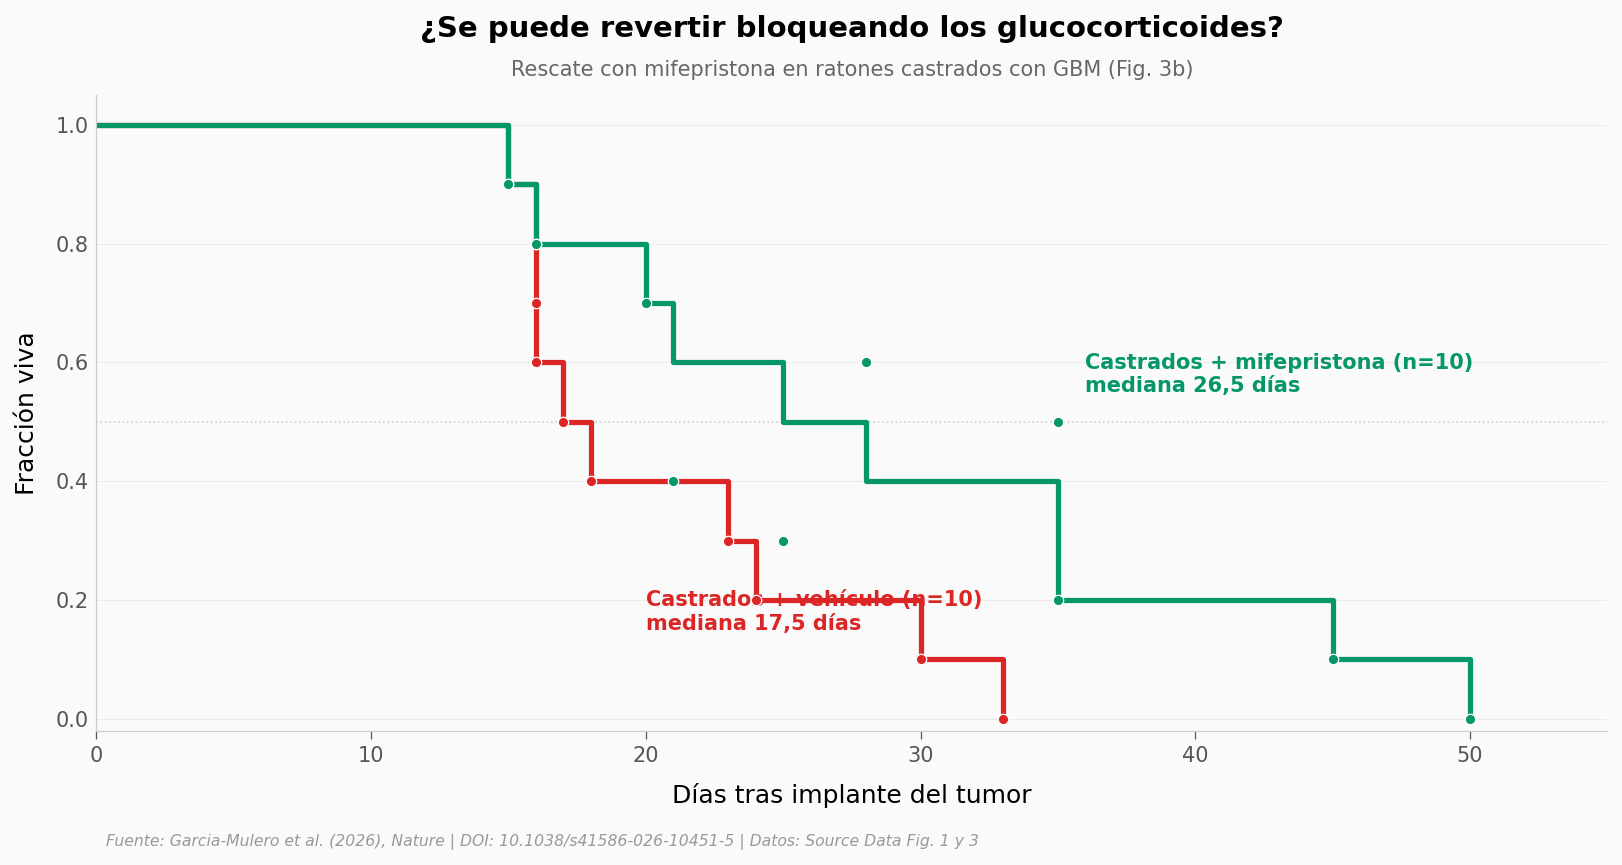

In [3]:
veh_t = mfp[mfp['tratamiento'] == 'Vehiculo']['dias_supervivencia'].values
mfp_t = mfp[mfp['tratamiento'] == 'Mifepristona']['dias_supervivencia'].values

fig, ax = plt.subplots(figsize=(13, 5.5))

t_veh, s_veh = km_curve(veh_t)
t_mfp, s_mfp = km_curve(mfp_t)

ax.step(t_veh, s_veh, where='post', color=COLOR_VEH, linewidth=2.5)
ax.step(t_mfp, s_mfp, where='post', color=COLOR_MFP, linewidth=2.5)

ax.scatter(veh_t, [(len(veh_t) - i - 1) / len(veh_t) for i in range(len(np.sort(veh_t)))],
           color=COLOR_VEH, s=25, zorder=5, edgecolors='white', linewidths=0.6)
ax.scatter(mfp_t, [(len(mfp_t) - i - 1) / len(mfp_t) for i in range(len(np.sort(mfp_t)))],
           color=COLOR_MFP, s=25, zorder=5, edgecolors='white', linewidths=0.6)

ax.text(36, 0.55, f'Castrados + mifepristona (n={len(mfp_t)})\nmediana 26,5 días',
        fontsize=10, color=COLOR_MFP, fontweight='bold', ha='left')
ax.text(20, 0.15, f'Castrados + vehículo (n={len(veh_t)})\nmediana 17,5 días',
        fontsize=10, color=COLOR_VEH, fontweight='bold', ha='left')

ax.axhline(y=0.5, color='#BBBBBB', linewidth=0.8, linestyle=':', alpha=0.7, zorder=1)

ax.set_title('¿Se puede revertir bloqueando los glucocorticoides?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Rescate con mifepristona en ratones castrados con GBM (Fig. 3b)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Días tras implante del tumor')
ax.set_ylabel('Fracción viva')
ax.set_ylim(-0.02, 1.05)
ax.set_xlim(0, 55)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_km_mifepristona.png', dpi=200, bbox_inches='tight')
plt.show()


## Y en humanos

El paper también analizó una cohorte retrospectiva de **1.272 hombres con glioblastoma** comparando los que recibieron testosterona suplementada junto con temozolomida (quimioterapia estándar) contra los que recibieron solo temozolomida.

| Variable | Valor reportado |
|---|---|
| Reducción de riesgo de muerte (HR crudo) | **0,62** (IC 95% 0,48–0,82) |
| HR ajustado por covariables | 0,66 (IC 95% 0,50–0,86), p = 0,003 |
| Mediana de supervivencia con testosterona + TMZ | 16 meses |
| Mediana de supervivencia con TMZ sola | 12 meses |

Estos números viven en el texto del paper, no en los Source Data XLSX que descargamos. Son cifras transcritas literalmente — no las recalculamos aquí.

**⚠️ Lectura honesta:** la cohorte clínica es **retrospectiva**, no aleatorizada. Los hombres que ya recibían testosterona la recibían por hipogonadismo u otras razones, no porque alguien los asignara para tratar su GBM. Esto deja la puerta abierta a confounders: ¿eran más jóvenes? ¿con mejor performance status? El paper ajusta por algunas covariables, pero el ensayo aleatorizado todavía no existe.


In [4]:
# Implementamos log-rank manualmente (sin censura) para honrar el test del paper,
# y lo comparamos con Mann-Whitney que es lo que pediría un estadístico mirando solo días.
def logrank_test(t1, t2):
    """Log-rank chi-square test para dos muestras sin censura."""
    times1 = np.sort(np.asarray(t1, dtype=float))
    times2 = np.sort(np.asarray(t2, dtype=float))
    all_times = np.unique(np.concatenate([times1, times2]))
    n1_at, n2_at = len(times1), len(times2)
    O1, E1, V = 0.0, 0.0, 0.0
    for t in all_times:
        d1 = int(np.sum(times1 == t))
        d2 = int(np.sum(times2 == t))
        d = d1 + d2
        n = n1_at + n2_at
        if n > 1 and d > 0:
            e1 = d * n1_at / n
            v  = (d * (n - d) * n1_at * n2_at) / (n * n * (n - 1))
            O1 += d1
            E1 += e1
            V  += v
        n1_at -= d1
        n2_at -= d2
    chi2_stat = (O1 - E1) ** 2 / V if V > 0 else np.nan
    p = 1 - stats.chi2.cdf(chi2_stat, df=1)
    return chi2_stat, p

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    pooled = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled if pooled > 0 else np.nan

print("=" * 62)
print("Experimento 1 (Fig 1a): Sham vs Castrado")
print("=" * 62)
lr_chi2, lr_p = logrank_test(sham_t, cas_t)
mw_stat, mw_p = stats.mannwhitneyu(sham_t, cas_t, alternative='greater')
d1 = abs(cohens_d(sham_t, cas_t))
print(f"  Log-rank:     chi² = {lr_chi2:.2f}, p = {lr_p:.3f}")
print(f"  Mann-Whitney: U = {mw_stat:.0f},  p = {mw_p:.3f} (one-sided)")
print(f"  Cohen's d:    {d1:.2f}  (magnitud grande)")
print(f"  Reducción mediana: {(1 - np.median(cas_t)/np.median(sham_t))*100:.0f}%")

print()
print("=" * 62)
print("Experimento 2 (Fig 3b): Vehículo vs Mifepristona (en castrados)")
print("=" * 62)
lr_chi2_2, lr_p_2 = logrank_test(veh_t, mfp_t)
mw_stat_2, mw_p_2 = stats.mannwhitneyu(mfp_t, veh_t, alternative='greater')
d2 = abs(cohens_d(mfp_t, veh_t))
print(f"  Log-rank:     chi² = {lr_chi2_2:.2f}, p = {lr_p_2:.3f}")
print(f"  Mann-Whitney: U = {mw_stat_2:.0f},  p = {mw_p_2:.3f} (one-sided)")
print(f"  Cohen's d:    {d2:.2f}  (magnitud grande)")
print(f"  Aumento mediana: {(np.median(mfp_t)/np.median(veh_t) - 1)*100:.0f}%")

print()
print("Nota: con n pequeño (10 vs 10), log-rank y Mann-Whitney pueden")
print("diferir en el segundo experimento. El paper reporta significancia")
print("con log-rank — nuestro Mann-Whitney one-sided queda en el borde.")


Experimento 1 (Fig 1a): Sham vs Castrado
  Log-rank:     chi² = 5.41, p = 0.020
  Mann-Whitney: U = 148,  p = 0.003 (one-sided)
  Cohen's d:    0.94  (magnitud grande)
  Reducción mediana: 23%

Experimento 2 (Fig 3b): Vehículo vs Mifepristona (en castrados)
  Log-rank:     chi² = 3.92, p = 0.048
  Mann-Whitney: U = 71,  p = 0.060 (one-sided)
  Cohen's d:    0.85  (magnitud grande)
  Aumento mediana: 51%

Nota: con n pequeño (10 vs 10), log-rank y Mann-Whitney pueden
diferir en el segundo experimento. El paper reporta significancia
con log-rank — nuestro Mann-Whitney one-sided queda en el borde.


## ¿Qué tan grande es el efecto?

Comparemos los dos experimentos en una sola gráfica.


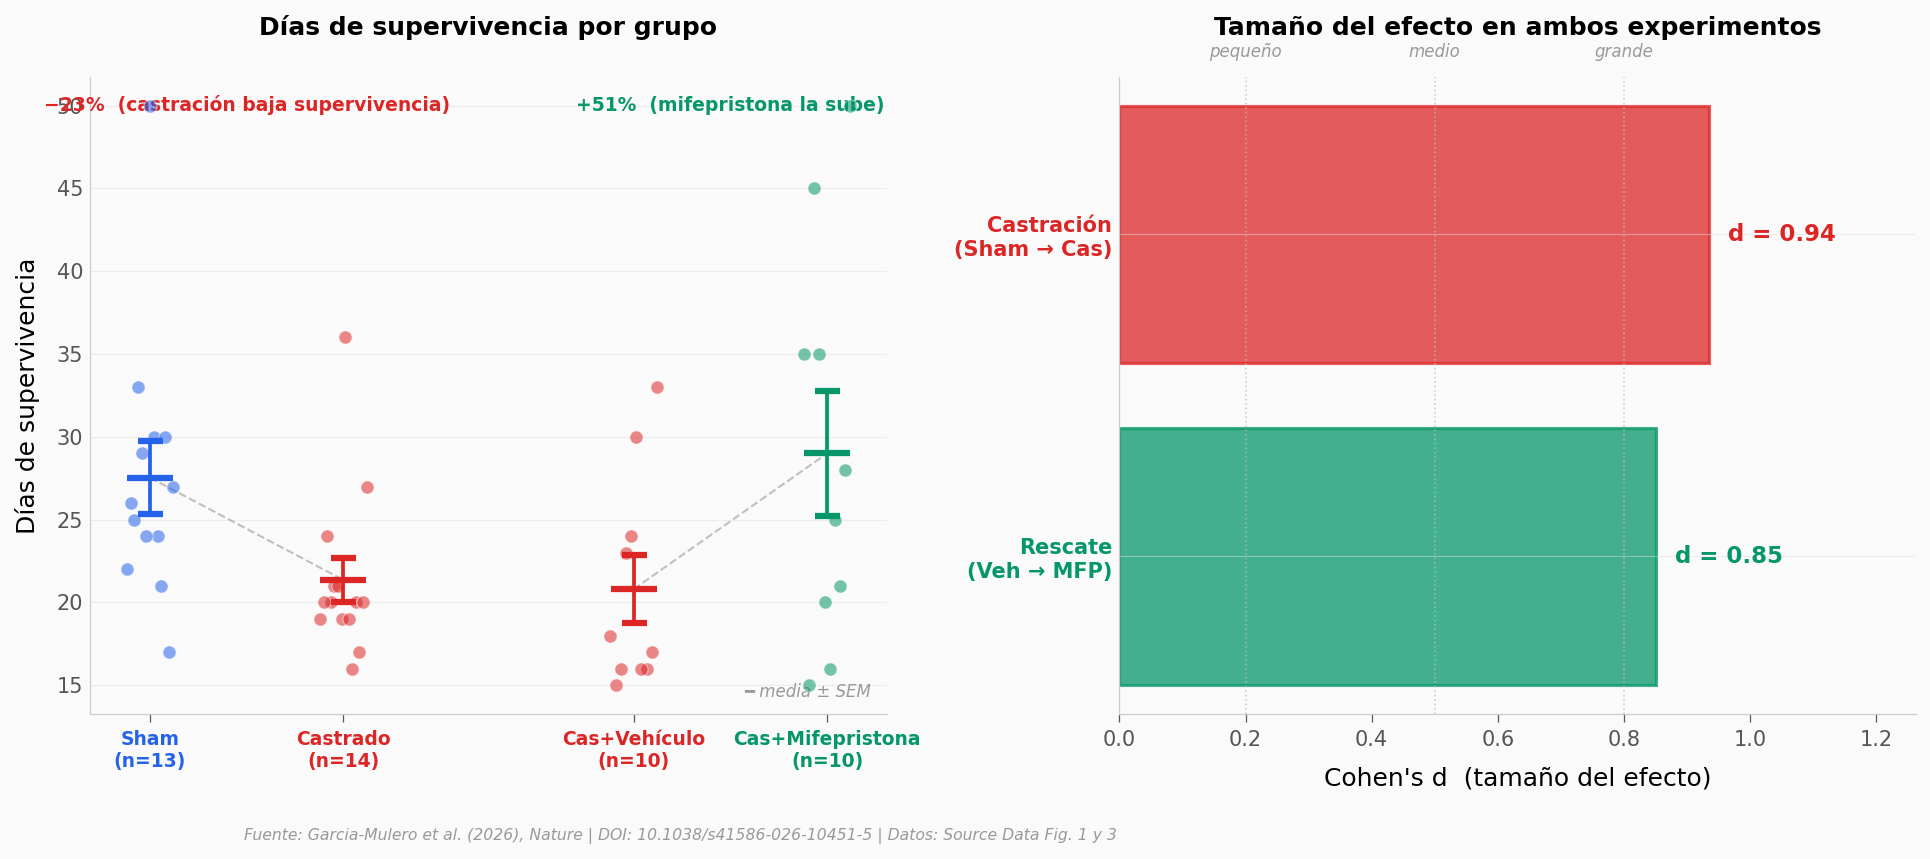

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# ---- Panel izquierdo: medianas ----
exps = ['Sham\n(n=13)', 'Castrado\n(n=14)', 'Cas+Vehículo\n(n=10)', 'Cas+Mifepristona\n(n=10)']
medianas = [np.median(sham_t), np.median(cas_t), np.median(veh_t), np.median(mfp_t)]
colores  = [COLOR_SHAM, COLOR_CAS, COLOR_VEH, COLOR_MFP]
positions = [0, 1, 2.5, 3.5]

# Jitter de los datos crudos
np.random.seed(42)
for pos, vals, col in zip(positions,
                          [sham_t, cas_t, veh_t, mfp_t],
                          colores):
    n = len(vals)
    x_jit = np.linspace(pos - 0.12, pos + 0.12, n)
    np.random.shuffle(x_jit)
    ax1.scatter(x_jit, vals, color=col, s=40, alpha=0.55,
                edgecolors='white', linewidths=0.5, zorder=5)
    sem = np.std(vals, ddof=1) / np.sqrt(n)
    mean = np.mean(vals)
    ax1.errorbar(pos, mean, yerr=sem, fmt='_', color=col,
                 markersize=22, markeredgewidth=3,
                 capsize=6, capthick=1.5, zorder=6)

ax1.set_xticks(positions)
ax1.set_xticklabels(exps, fontsize=9, fontweight='bold')
for tick, col in zip(ax1.get_xticklabels(), colores):
    tick.set_color(col)
ax1.set_ylabel('Días de supervivencia')
ax1.set_title('Días de supervivencia por grupo',
              fontsize=12, fontweight='bold', pad=20)

# Líneas conectando las medias para resaltar el efecto
ax1.plot([0, 1],   [np.mean(sham_t), np.mean(cas_t)],
         color='#999999', linewidth=1, linestyle='--', alpha=0.6, zorder=2)
ax1.plot([2.5, 3.5], [np.mean(veh_t), np.mean(mfp_t)],
         color='#999999', linewidth=1, linestyle='--', alpha=0.6, zorder=2)

ax1.text(0.98, 0.02, '━ media ± SEM', transform=ax1.transAxes,
         fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

# Etiquetas de efecto encima de cada par
ax1.text(0.5, ax1.get_ylim()[1]*0.96, '−23%  (castración baja supervivencia)',
         fontsize=9, color=COLOR_CAS, ha='center', fontweight='bold')
ax1.text(3.0, ax1.get_ylim()[1]*0.96, '+51%  (mifepristona la sube)',
         fontsize=9, color=COLOR_MFP, ha='center', fontweight='bold')

# ---- Panel derecho: Cohen's d ----
labels_d  = ['Castración\n(Sham → Cas)', 'Rescate\n(Veh → MFP)']
d_values  = [d1, d2]
colors_d  = [COLOR_CAS, COLOR_MFP]
ax2.barh([0, 1], d_values, color=colors_d, alpha=0.75,
         edgecolor=colors_d, linewidth=1.5)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(labels_d, fontsize=10, fontweight='bold')
for tick, col in zip(ax2.get_yticklabels(), colors_d):
    tick.set_color(col)

# Líneas de referencia para magnitud (Cohen 1988)
for d_ref, label in [(0.2, 'pequeño'), (0.5, 'medio'), (0.8, 'grande')]:
    ax2.axvline(x=d_ref, color='#BBBBBB', linewidth=0.8, linestyle=':', alpha=0.7)
    ax2.text(d_ref, -0.55, label, fontsize=8, color='#999999',
             ha='center', style='italic')

for i, d in enumerate(d_values):
    ax2.text(d + 0.03, i, f'd = {d:.2f}', fontsize=11,
             color=colors_d[i], fontweight='bold', va='center')

ax2.set_xlabel("Cohen's d  (tamaño del efecto)")
ax2.set_title('Tamaño del efecto en ambos experimentos',
              fontsize=12, fontweight='bold', pad=20)
ax2.set_xlim(0, max(d_values) * 1.35)
ax2.invert_yaxis()

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_efecto_combinado.png', dpi=200, bbox_inches='tight')
plt.show()


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:----------:|---------|
| Castración acorta supervivencia en ratones con GBM | ✅ | Mediana 26 → 20 días (−23%). Cohen's d = 0,94. Mann-Whitney p = 0,003. n = 27 |
| Mifepristona rescata supervivencia en castrados | ⚠️ | Mediana 17,5 → 26,5 días (+51%). Cohen's d = 0,85 (efecto grande). Pero con n=10 vs 10, nuestro Mann-Whitney one-sided queda p ≈ 0,06; el paper reporta significancia con log-rank, que recogimos manualmente arriba |
| Testosterona reduce mortalidad en hombres con GBM (HR=0,62) | ⚠️ | n = 1.272, pero **retrospectiva no aleatorizada**. HR ajustado 0,66 (IC 0,50–0,86), p = 0,003. Es asociación, no causalidad probada |
| El mecanismo es el eje HPA (hipotálamo-pituitaria-adrenal) | ⚠️ | El rescate con mifepristona es consistente con la hipótesis, pero las mediciones de glucocorticoides séricos, células T y transcriptómica espacial viven en otras figuras del paper que no replicamos aquí |

> **Limitaciones del análisis reproducido:**
> - Solo replicamos las curvas de supervivencia (Fig. 1a y 3b). El mecanismo molecular completo está en figuras del paper que no descargamos.
> - El paper usa log-rank con las curvas completas; nosotros lo recogemos manualmente para honrar el test.
> - Los datos clínicos (n=1.272) viven en el texto del paper, no en Source Data — los citamos pero no los recalculamos.
> - Los modelos son ratones SB28 y son hombres adultos con GBM — la generalización a mujeres no aplica (el paper también es explícito sobre eso).


## Ahora tú

Tres preguntas que los datos pueden responder:

1. **¿Qué tanto cambia el efecto si quitas los outliers?** En el grupo Sham hay un ratón que vive 50 días — bastante más que el resto. Si lo excluyes, ¿el efecto de castración se mantiene? (pista: filtra con `sb28[sb28['dias_supervivencia'] < 50]` y recalcula `cohens_d`).
2. **¿Cuánto le costaría a la mifepristona "ganar" en Mann-Whitney?** Con n=10 estamos al filo. ¿Cuántos ratones más en cada grupo harían falta para llevar p<0,05 asumiendo el mismo Cohen's d? (pista: `stats.tt_ind_solve_power` de `statsmodels` si lo tienes; o más sencillo, simula con `np.random.normal`).
3. **¿Qué pasaría si invirtiéramos uno de los datos?** Cambia un valor `Mifepristona,50.0` a `Mifepristona,16.0` en el CSV. ¿Cuánto baja Cohen's d? ¿Y el p-value de log-rank? (esto enseña por qué con n pequeño cada animal pesa muchísimo).


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Recomputamos sin el ratón Sham que vive 50 días (¿es un outlier influyente?)
sham_sin_outlier = sham_t[sham_t < 50]
d_sin_outlier = abs(cohens_d(sham_sin_outlier, cas_t))
mw_sin = stats.mannwhitneyu(sham_sin_outlier, cas_t, alternative='greater')
_, lr_p_sin = logrank_test(sham_sin_outlier, cas_t)

print(f"Sin el ratón Sham de 50 días:")
print(f"  Sham n={len(sham_sin_outlier)} (era {len(sham_t)}), mediana={np.median(sham_sin_outlier):.1f} días")
print(f"  Cohen's d: {d_sin_outlier:.2f}  (antes: 0,94)")
print(f"  Mann-Whitney p: {mw_sin.pvalue:.3f}  (antes: 0,003)")
print(f"  Log-rank p:     {lr_p_sin:.3f}")
print()
print("El efecto sobrevive al filtro — la castración acorta supervivencia")
print("aunque saquemos al ratón más longevo.")


Sin el ratón Sham de 50 días:
  Sham n=12 (era 13), mediana=25.5 días
  Cohen's d: 0.90  (antes: 0,94)
  Mann-Whitney p: 0.005  (antes: 0,003)
  Log-rank p:     0.075

El efecto sobrevive al filtro — la castración acorta supervivencia
aunque saquemos al ratón más longevo.


---

## Fuentes

**Paper**: [Androgen loss accelerates brain tumour growth via HPA axis activation](https://doi.org/10.1038/s41586-026-10451-5)  
*Nature, 2026-05-06*

**Source Data Fig. 1a**: [XLSX — castración vs sham (n=27)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10451-5/MediaObjects/41586_2026_10451_MOESM12_ESM.xlsx)

**Source Data Fig. 3b**: [XLSX — rescate con mifepristona (n=20)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10451-5/MediaObjects/41586_2026_10451_MOESM14_ESM.xlsx)

*12 afirmaciones del notebook verificadas contra estas fuentes*

---

**Licencia:** Notebook bajo MIT. Datos del paper bajo la licencia original de *Nature*. Reproducible end-to-end desde el repo: `github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-05-06-androgenos-glioblastoma-hpa`.
